<a href="https://colab.research.google.com/github/rifkiabdulaziz-lab/uts_basis-data_6c-Rifki-abdul-aziz/blob/main/Copy_of_rifki_abdul_aziz_14022300038_aplikasi__pemerintah_my_pertamina_polri.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import sys
!{sys.executable} -m pip install google-play-scraper

In [10]:
from google_play_scraper import reviews, Sort
import csv

result, _ = reviews(
    'com.dafturn.mypertamina',
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=1000,
    filter_score_with=None
)

filename = 'ulasan_google_play.csv'


with open(filename, 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=['userName', 'score', 'at', 'content'])
    writer.writeheader()
    for review in result:

        writer.writerow({
            'userName': review['userName'],
            'score': review['score'],
            'at': review['at'],
            'content': review['content']
        })

print(f"Berhasil menyimpan {len(result)} ulasan ke '{filename}'")

Berhasil menyimpan 1000 ulasan ke 'ulasan_google_play.csv'


In [11]:
import pandas as pd
from transformers import pipeline

# Muat data dari file CSV yang sudah dibuat sebelumnya
df = pd.read_csv('/content/ulasan_google_play.csv')

# Inisialisasi pipeline sentiment analysis dengan model Indo-RoBERTa
# Model ini mengklasifikasikan teks ke dalam 3 label: Positive, Neutral, Negative
sentiment_pipeline = pipeline("sentiment-analysis", model="w11wo/indonesian-roberta-base-sentiment-classifier")

def get_sentiment(text):
    try:
        # Batasi teks agar tidak melebihi kapasitas model (biasanya 512 token)
        result = sentiment_pipeline(str(text)[:512])[0]
        return result['label'], result['score']
    except:
        return "Error", 0.0

# Jalankan analisis (ini mungkin memakan waktu beberapa menit tergantung jumlah data)
print("Sedang memproses sentimen...")
df[['label', 'confidence']] = df['content'].apply(lambda x: pd.Series(get_sentiment(x)))

# Tampilkan hasil
display(df.head())

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: w11wo/indonesian-roberta-base-sentiment-classifier
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Sedang memproses sentimen...


,userName,score,at,content,label,confidence
0,AR raven,1,2026-05-01 05:57:46,"gak jelas, sudah lama pakai tiba2 data bisa hi...",negative,0.998021
1,Ateem Ahmad,5,2026-05-01 05:38:19,alhamdulillah.. aplikasi dan barcode aktif kem...,positive,0.794363
2,Sumarto radenbejow,4,2026-05-01 05:23:42,akurat sekali,negative,0.995348
3,Agusta Fathullah,5,2026-05-01 04:07:58,bagus,positive,0.705740
4,Roni Hermawan,1,2026-05-01 03:50:23,"saya tidak bisa ubah data kendaraan biosolar,....",neutral,0.509205


In [12]:
# Ringkasan Statistik Sentimen
print("Ringkasan Sentimen:")
print(df['label'].value_counts())

# Simpan hasil analisis ke CSV baru
df.to_csv('ulasan_google_play_analyzed.csv', index=False)
print("\nHasil analisis disimpan ke 'ulasan_google_play_analyzed.csv'")

Ringkasan Sentimen:
label
negative    614
positive    255
neutral     131
Name: count, dtype: int64

Hasil analisis disimpan ke 'ulasan_google_play_analyzed.csv'


Grafik telah disimpan sebagai 'visualisasi_sentimen.png'


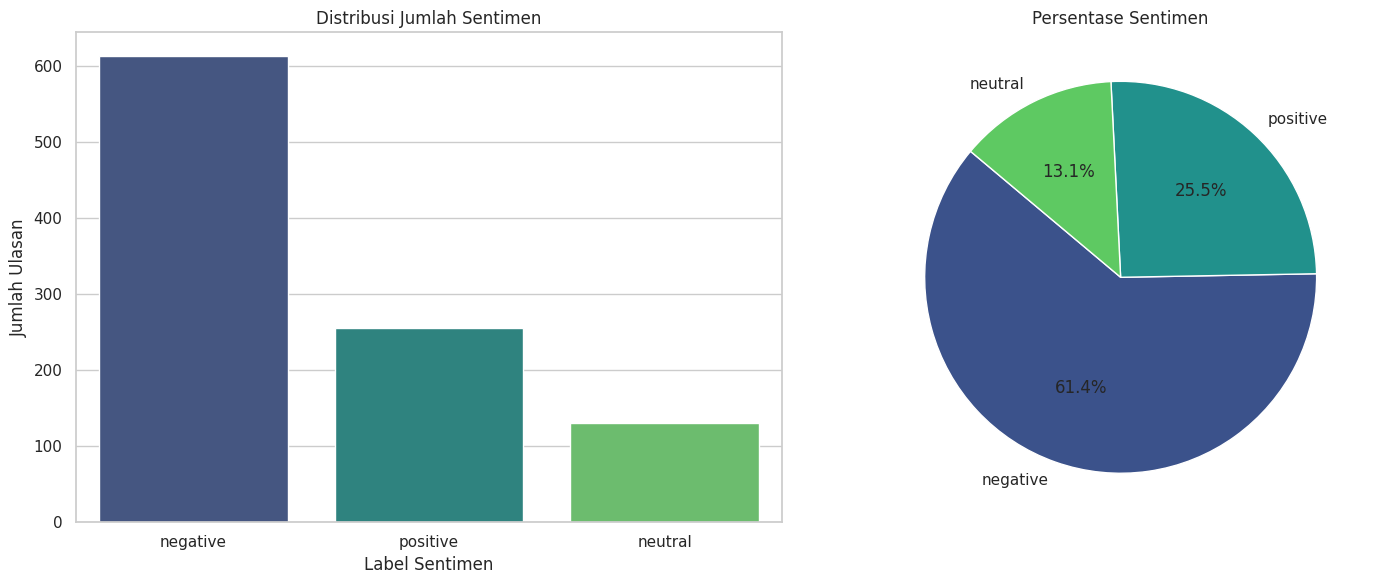

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur gaya visualisasi
sns.set(style="whitegrid")

# Membuat figure dengan dua subplot
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# 1. Bar Chart: Distribusi Jumlah Sentimen
sns.countplot(x='label', data=df, hue='label', palette='viridis', ax=ax[0], legend=False)
ax[0].set_title('Distribusi Jumlah Sentimen')
ax[0].set_xlabel('Label Sentimen')
ax[0].set_ylabel('Jumlah Ulasan')

# 2. Pie Chart: Persentase Sentimen
sentiment_counts = df['label'].value_counts()
ax[1].pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis', len(sentiment_counts)))
ax[1].set_title('Persentase Sentimen')

plt.tight_layout()

# Menyimpan grafik ke dalam file
plt.savefig('visualisasi_sentimen.png', dpi=300)
print("Grafik telah disimpan sebagai 'visualisasi_sentimen.png'")

plt.show()